# **Data Preprocessing**

> The first four sections of my file contains the data cleaning process of the dataset I chose to use.



# **Dataset Selection and Preparation**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

This module loads necessary libraries for data preprocessing, visualization, and handling so that the dataset is clean and ready for analysis and modeling.

- pandas and numpy support **data structure manipulation and numeric computation** as the foundation for data processing.
- matplotlib.pyplot and seaborn are used to **successfully visualize data trends, distributions, and relationships** as they are indispensable in exploratory data analysis.
- missingno facilitates the **identification and visualization of missing values**, enabling effective data cleaning techniques.
- OneHotEncoder ensures that **categorical variables are correctly converted to numerical form** so that they can be used with machine learning algorithms.
- MinMaxScaler and StandardScaler **scale numerical features**, avoiding problems arising from varying scales and ensuring that models learn effectively.

This block is useful since it **lays down the requisite tools for preprocessing the data**, which is a fundamental step toward constructing correct and robust machine learning models.



In [ ]:
df = pd.read_csv("weather_classification_data.csv", delimiter=",", encoding='latin-1')

print(df.head())

This code reads the "weather_classification_data.csv" file into a pandas DataFrame with `pd.read_csv()`. The delimiter="," instructs it that the columns are commas rather than semicollon-delimited. The encoding='latin-1' is included to ensure special characters, like accented letters, are read properly.

The `print(df.head())` call prints out the **first five records** of the dataset to provide an initial look at its structure and composition. This step verifies if and when the data has loaded and been formatted correctly prior to further in-depth analysis.

In [ ]:
print("Initial shape of the dataset:", df.shape)

This line displays the original structure of the dataset through df.shape, which provides a tuple giving the number of rows and columns in the DataFrame. The first element is the number of overall records `(Temperature)`, and the second is the number of features `(statistical columns)`.

It is important to know the size of the dataset **prior to any preprocessing**, be it cleaning or feature selection.

In [ ]:
print("Intial columns of the dataset:\n", df.columns)

This print statement prints out the first column headers of the dataset using df.columns, a list-like object that holds all column headers. By printing the column headers, **we have a view of available attributes in the dataset** so that we can discover useful features for analysis and flag any inconsistencies such as unusual symbols, spaces, or missing labels.

In [ ]:
columns_to_drop = ['Cloud Cover', 'Location', 'Season']
df = df.drop(columns=columns_to_drop)

This block deletes the following columns from the data by employing the `drop()` method. Eliminating "Cloud Cover," "Location," and "Season" is required to enhance model precision and generality:

- "Cloud Cover" is redundant because "Weather Type" already provides the same description, which can lead to multicollinearity.

- "Season" is too general and indirectly correlated with day-to-day weather, as characteristics such as temperature and humidity already provide better coverage of seasonal variations

- "Location" does not add useful numerical information and can result in overfitting, where the model learns regional weather by heart rather than general trends.

Removing these columns removes noise, avoids bias, and makes the model learn real weather conditions, resulting in improved predictive accuracy.

In [ ]:
df.head()

The following code then displays the first five records of the dataset after dropping the mentioned columns.There are only **8 columns** remaining at this point

In [ ]:
df.info()

The `df.info()` display presents an overview of the dataset where the number of rows is 13200, and the number of columns is 8. In addition, each column's data type is included.

Columns that contains numeric data types:

- `int64` for categorical or count-based variables such as `Humidity` and `UV Index`.
- `float64` for continuous statistics like `Temperature` and `Wind Speed`.

Columns that contains categorical data types:
- `Weather Type`

This overview aids in measuring the completeness of the dataset and is helpful in preprocessing operations, including encoding categorical variables and scaling numerical ones for machine learning algorithms.

In [ ]:
df.dtypes

The df.dtypes function shows the data types in every column in the data set. It ensures that the **columns are numerical, with int64 applied to whole numbers** such as **Humidity** and **UV Index** while **float64 is applied to percentage-based and continuous numerical variables** like **Precipitation (%)** and **Atmospheric Pressure**. **Weather Type** is an **object type column, meaning categorical data**.

In [ ]:
df.hist(bins=50, figsize=(20,15))
plt.show()

The block of code produces histograms for each of the numerical variables in the data set with 50 bins per variable. The `figsize=(20,15)` argument sets the plots large and legible. Histograms can be employed to view the **distribution of each variable and identify if there are trends such as skewness, outliers, or whether the data is normally distributed**. This can be **helpful in feature selection, normalization, or transformation** prior to applying machine learning algorithms. The `plt.show()` function plots the histograms.

The histograms show how different weather variables are distributed. **Wind Speed, UV Index, and Visibility** have most values on the lower end, with a few extreme cases. **Temperature and Humidity** have multiple peaks, likely due to seasonal changes. **Precipitation and Atmospheric Pressure** vary more evenly. These patterns help identify trends, outliers, and whether the data needs adjustments before using machine learning models.

In [ ]:
for column in df:
    print(f"Unique values in {column}:", df[column].nunique())
    print(f"Missing values in {column}:", df[column].isnull().sum())
    print()

This code loop through every column in the data set and prints the number of unique values `nunique()` and the count of missing values `isnull().sum()` per column. The **unique values assist in recognizing categorical variables** and **measuring variability** in the data, while **missing values indicate potential data quality problems** that might need to be imputed or dropped.

In [ ]:
df.to_csv('cleaned - weather_classification_data.csv', index=False)

This line of code saves the current dataset up to this point, and I have used it several times in this activity in order to save all the processes, to receive the cleaned dataset file whenever needed.

# **Handling Missing Values**


In [ ]:
missing_values = df.isnull().sum()
print(missing_values.to_dict())

The code counts and prints missing values in every column of the dataset. `df.isnull().sum()` calculates the null values in every column, and `.to_dict()` transforms the result into dictionary form for easy readability. The used dataset ***contains no missing values, so, all columns hold complete data for all entries***. This is a good since it eliminates imputation or data cleaning on missing values, and we can move forward with analysis without concerns of incomplete records.

In [ ]:
df.dropna(axis=1, how='all', inplace=True)

print("Remaining columns:")
print(df.columns)

The line of code `df.dropna(axis=1, how='all', inplace=True)` deletes columns consisting solely of missing values `(NaN)`. Because there are no missing values in the dataset as can be seen in the above output, **no columns will be deleted**, and **df.columns will still have all the columns** as originally presented.

In [ ]:
df.dropna(inplace=True)

print("Shape of DataFrame after removing rows with missing values:", df.shape)

The line `df.dropna(inplace=True)` deletes rows containing missing values, changing the DataFrame in place. Since the prior run of code indicated no missing values, this action did not affect the dataset. The shape is still `(13200,8)`, so all rows and columns remains.

In [ ]:
print("Columns of the dataset after handling missing values:\n", df.columns)

print("\nShape of DataFrame after removing columns with missing values:", df.shape)

This code checks the DataFrame's structure after the missing values were dealt with. It initially **prints the column headers** to ensure no critical data was lost. Then it **prints the shape of the DataFrame**, which indicates the number of rows and columns. Since no missing values were found before, the **dataset is still intact at (13200,8)**, which ensures data integrity.

In [ ]:
df.to_csv('cleaned - weather_classification_data.csv', index=False)

The current dataset condition is saved again, after handling missing values.

# **Dealing with Duplicates**

In [ ]:
for column in df.columns:
    print(f"Unique values in {column}:", df[column].nunique())
    print(f"Number of duplicates in '{column}' column: {df[column].duplicated().sum()} \n")

This loop iterates over all columns in the DataFrame to check for its uniqueness and duplication. It first prints the **number of unique values in each column**, which can be utilized to **detect categorical variables or redundancies**. It then c**hecks for duplicate values in each column**, which can be utilized to **detect inconsistencies or repetitions** in the dataset. This is to verify data quality prior to further processing.

Categorical columns like **Weather Type** have very few unique values, making them useful for classification tasks. In contrast, numerical columns such as **Temperature, Humidity, and Atmospheric Pressure** have many unique values, indicating continuous data. The high number of duplicates in some columns suggests repeated or similar weather conditions, which is important to consider when analyzing trends or training models.

In [ ]:
unique_columns = []
for column in df.columns:
    if df[column].nunique() == len(df):
        unique_columns.append(column)

print("Columns where each row is unique:")
print(unique_columns)

It then checks if columns have all unique values and no duplicate values. It does this by comparing the total unique number of values in each column `df[column].nunique()` and the total rows `len(df)`. The column will only be considered unique when the two are equal, hence appending it to unique_columns. Since the output is an empty list `[]`, this shows that **none of the columns in the data contains entirely unique values**. There are at least some duplicated records in every column.

In [ ]:
for column in df.columns:
    print(f"Unique values in column '{column}':")
    print(df[column].unique())
    print()

This script loops over every column in the DataFrame and prints out all the unique values in that column. The `df[column].unique()` command gets an array of unique values in the column, which enables a view of the variability of the dataset. This assists in detecting **categorical values, possible inconsistencies, and patterns** in the data. The extra newline (`print()`) provides easier readability by inserting a newline for each column.

In [ ]:
df.duplicated().sum()

This line checks how many duplicate rows exist in the dataset. Since it printed 0, this means there are **no fully identical rows**. I concluded that I won’t delete any duplicate values because, while some individual columns have repeated values, **they are not exact row duplicates**, meaning they still provide useful information for analysis.

In weather data, multiple instances of the same temperature, humidity, or wind speed are expected across different days and times. Since no entire row is duplicated, **each record still contributes uniquely to the dataset**. Removing these values could lead to **loss of important variations in weather conditions**, which are essential for building an accurate classification model.

In [ ]:
df.to_csv('cleaned - weather_classification_data.csv', index=False)

Once again, I saved the current condition of the dataset after handling duplicate values.

# **Dealing with Outliers**

In [ ]:
def detect_outliers_iqr(df):
    outliers = {}
    for column in df.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        column_outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
        if not column_outliers.empty:
            outliers[column] = column_outliers
    return outliers

outliers_iqr = detect_outliers_iqr(df)

for column, values in outliers_iqr.items():
    plt.figure(figsize=(8, 6))
    plt.boxplot(df[column], vert=False, patch_artist=True, showmeans=True)
    plt.title(f'Boxplot of {column} (with outliers)')
    plt.show()


The code identifies outliers based on the **Interquartile Range (IQR)** method and plots them via boxplots. It then loops over all the numeric columns of the data, namely** float64 and int64**.

- For each column, it computes the **first quartile (Q1), third quartile (Q3)**, and the **interquartile range (IQR**), which is the difference between Q3 and Q1.

- With this, it calculates the lower and upper limits by subtracting and adding 1.5 times the IQR from Q1 and Q3, respectively.

- Any values outside these limits are considered outliers and are placed in a dictionary. If there are outliers in a column, a boxplot is created to **visually show the distribution of values, including the extreme values**.

This helped me identify strange data points that could require additional analysis or preprocessing, since **I also didn't know my dataset had a lot of outliers prior to executing this block of code**.

In [ ]:
def remove_outliers_iqr(df):
    cleaned_df = df.copy()
    for column in df.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        cleaned_df = cleaned_df[(cleaned_df[column] >= lower_bound) & (cleaned_df[column] <= upper_bound)]
    return cleaned_df

df_cleaned = remove_outliers_iqr(df)

for column in df_cleaned.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(8, 6))
    plt.boxplot(df_cleaned[column], vert=False, patch_artist=True, showmeans=True)
    plt.title(f'Boxplot of {column} (without outliers)')
    plt.show()

The next code then **eliminates outliers by the IQR method and subsequently plots the cleaned data**. It first makes a copy of the dataset and computes Q1, Q3, and IQR for every numeric column. **Any values that are more than 1.5 times the IQR away** from Q1 and Q3 are removed, leaving a cleaned dataset free of outliers. It then creates **boxplots for the cleaned columns to display the new distributions**.

In [ ]:
df.to_csv('cleaned - weather_classification_data.csv', index=False)

The dataset is saved again upon this point.

In [ ]:
df = df_cleaned.copy()

print("Shape of the cleaned dataset::", df.shape)

This code creates a new DataFrame with the same number of rows and columns but not copying its actual data. It creates **an empty DataFrame with the same shape instead**. The print statement then verifies that **the cleaned dataset has 11689 rows and 8 columns**.

In [ ]:
print("Columns of the cleaned dataset::\n", df_cleaned.columns)

num_columns = len(df_cleaned.columns)

print("\nNumber of columns in the dataset after cleaning:", num_columns)

The code prints the column headers of `df_cleaned` first, showing that **all 8 columns are still intact** after cleaning. The code then counts and prints the number of columns, confirming that no columns were dropped but rows with outliers were filtered instead. This makes sure that the dataset maintains its original form without extreme values.

In [ ]:
df.to_csv('cleaned - weather_classification_data.csv', index=False)

In [ ]:
numerical_columns = df_cleaned.select_dtypes(include=['float64', 'int64']).columns

df_cleaned[numerical_columns].hist(bins=50, figsize=(20, 15))
plt.show()

The code generates histograms for all numeric columns in the dataset, visualizing the distribution of values within different bins. These plots illustrate how the weather-related variables are distributed within the cleaned dataset.

- Several variables, such as **UV Index and Wind Speed**, exhibit right-skewed distributions, where most values are **concentrated at lower levels** with some higher outliers.
- Other features, like **Temperature and Precipitation (%)**, display multimodal distributions, indicating the **presence of multiple distinct weather patterns or seasonal variations**.
- **Atmospheric Pressure appears more normally distributed**, while Visibility (km) shows a sharp drop-off at higher values, suggesting a **limit on maximum recorded visibility**.

The chosen bin size provides clear granularity, making it easier to identify patterns and variations in weather conditions. This distribution analysis helps in understanding data characteristics, detecting potential anomalies, and preparing for further preprocessing steps.

# **Multinomial Logistic Regression (MLR): Code Explanation**


> This section now covers the code function for the MLR Algorithm, with the following sections discussing the experimentation.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

This block loads major Python libraries for data processing, visualization, and machine learning:

**pandas and numpy**
- Manage data manipulation and numerical computations.

**matplotlib.pyplot and seaborn**
- Produce plots for data visualization.

**sklearn.model_selection**
- Offers functionality for dataset splitting and cross-validation (KFold, cross_val_score, train_test_split).

**sklearn.preprocessing**
- Offers StandardScaler for feature scaling and LabelEncoder for categorical encoding.

**sklearn.linear_model.LogisticRegression**
- Classifies Multinomial Logistic Regression (MLR).

**sklearn.metrics**
- Calculates performance metrics such as the confusion matrix and classification report.

This configuration facilitates fluent data processing, model training, and testing in the MLR experiment.

In [ ]:
# Load dataset
file_path = "cleaned - weather_classification_data.csv"
df = pd.read_csv(file_path)

# Features and target variable
X = df.drop(columns=["Weather Type"])
y = df["Weather Type"]

This code is used to read the dataset in a CSV format into a Pandas DataFrame and prepare it for machine learning. It is split into independent variables and the dependent variable. The variable `X` holds all except "Weather Type," which is the target variable held in `y`.

Separating it will allow the machine learning model to be trained by the input features to forecast the weather type.

In [ ]:
# Encode target variable
le = LabelEncoder()
y = le.fit_transform(y)

This code converts the categorical "Weather Type" into numerical values using `LabelEncoder`, as machine learning models like Logistic Regression require numerical input. The `fit_transform` method assigns each category a unique integer, making it suitable for classification while preserving categorical distinctions.

In [ ]:
# Split data for evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

This code splits the dataset into training (80%) and testing (20%) sets using `train_test_split`, with `random_state=42` ensuring reproducibility. The training set is used to train the model, while the test set evaluates its performance. The `random_state` value can be changed or omitted, affecting how the data is split and potentially influencing model performance. Keeping it fixed ensures consistent results across executions.

In [ ]:
# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

This code standardizes the numerical features using **StandardScaler**, which scales the data to have a mean of 0 and a standard deviation of 1. Standardization helps improve model performance by ensuring that all features contribute equally, preventing dominance by larger-valued features. The scaler is first fitted to **X_train** and then applied to both **X_train** and **X_test** to maintain consistency.

In [ ]:
# Define multinomial logistic regression model
model = LogisticRegression(C=1.0, solver="lbfgs", max_iter=1000) #multi_class="multinomial"

This code defines a multinomial logistic regression model using `LogisticRegression` from scikit-learn. The `C=1.0` parameter controls regularization strength, `solver="lbfgs"` is an optimization algorithm suited for multinomial classification, and `max_iter=1000` ensures sufficient iterations for convergence.

The `multi_class="multinomial"` argument was removed because `lbfgs` automatically supports multinomial classification when the target variable has more than two classes. By default, scikit-learn detects this and applies the appropriate setting, making the explicit argument unnecessary.

In [ ]:
# Implement k-fold cross-validation (k=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring="accuracy")

This code implements **k-fold cross-validation** with `k=5`, meaning the training data is split into five subsets. The model is trained on four folds and tested on the remaining one, repeating this process five times to ensure a balanced evaluation.  

- `KFold(n_splits=5, shuffle=True, random_state=42)`: Creates a 5-fold split, shuffling the data before splitting to reduce bias. The fixed `random_state=42` ensures reproducibility.  
- `cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring="accuracy")`: Trains and evaluates the model on each fold, computing accuracy scores across all iterations.  

This approach provides a more **robust** assessment of model performance compared to a single train-test split.

In [ ]:
# Train model on full training set
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred1 = model.predict(X_test_scaled)

This code trains the **multinomial logistic regression model** on the entire training dataset and generates predictions on the test set.  

- `model.fit(X_train_scaled, y_train)`: Fits the logistic regression model using the standardized training data after standardizing the training data with StandardScaler. The model learns the relationship between input features and the target variable.  
- `model.predict(X_test_scaled)`: Uses the trained model to predict class labels for the test dataset based on the learned patterns.  

Training on the full dataset ensures the model captures as much information as possible, while making predictions on unseen data helps assess its generalization performance. The predicted labels can then be compared with actual values to evaluate accuracy and other metrics.

In [ ]:
# Visualization: Line chart of accuracies
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(scores)+1), scores, marker="o", linestyle="-", color="blue", label="Fold Accuracy")
plt.axhline(y=scores.mean(), color="red", linestyle="--", label=f"Mean Accuracy: {scores.mean():.4f}")
plt.title("Model Performance Across Folds")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.xticks(range(1, len(scores) + 1))
plt.ylim(0.8, 1.0)  # Adjust based on expected accuracy range
plt.legend()
plt.grid(True)

# Show plot
plt.show()

# Print cross-validation results
print(f"Accuracy Score per Fold: {scores}")
print(f"Overall Mean Accuracy: {scores.mean():.4f}")

This code evaluates and visualizes the **performance of the multinomial logistic regression model** using k-fold cross-validation.  

- The `plt.plot()` function creates a **line chart** where each point represents the **accuracy** of the model in a specific fold.  
- The `plt.axhline()` adds a **red dashed horizontal line** at the mean accuracy, providing a reference point to compare individual fold performances.  
- The x-axis represents **fold numbers**, and the y-axis shows **accuracy values**, with limits set between **0.8 and 1.0** to focus on relevant accuracy ranges.  
- `plt.legend()` labels the accuracy line and mean accuracy for easy interpretation, while `plt.grid(True)` enhances readability by adding grid lines.  


- `print(f"Accuracy Score per Fold: {scores}")` outputs the **accuracy for each fold**, showing variations in performance.  
- `print(f"Overall Mean Accuracy: {scores.mean():.4f}")` provides the **average accuracy across all folds**, offering an overall measure of model performance.

This ensures the model is evaluated on multiple data splits, helping assess its stability, consistency, and generalization ability across different subsets of data.

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred1), annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Baseline Model")
plt.show()


print("Classification Report - Baseline Model:")
print(classification_report(y_test, y_pred1))

This code evaluates the **classification performance** of the multinomial logistic regression model using a **confusion matrix heatmap** and a **classification report**.  

### **Confusion Matrix Heatmap**  
- `confusion_matrix(y_test, y_pred1)`: Computes the confusion matrix, which shows how many instances of each class were correctly or incorrectly classified.  
- `sns.heatmap()`: Visualizes the confusion matrix using Seaborn, where:  
  - `annot=True` displays the actual count values in each cell.  
  - `fmt='d'` ensures values are shown as whole numbers.  
  - `cmap='Blues'` colors the heatmap for better clarity.  
  - `xticklabels=le.classes_` and `yticklabels=le.classes_` label the axes with the original class names.  
- The heatmap makes it easier to analyze **misclassifications** and identify which classes the model struggles with.  

### **Classification Report**  
- `classification_report(y_test, y_pred1)`: Generates a detailed performance summary, including:  
  - **Precision**: How many predicted positives were actually correct.  
  - **Recall**: How many actual positives were correctly predicted.  
  - **F1-score**: The balance between precision and recall.  
  - **Support**: The number of actual instances per class.  
- Printing this report helps in assessing the model’s strengths and weaknesses across different classes.  

This provides a **clear evaluation of model accuracy, class-wise performance, and areas needing improvement**.

# **MLR Experimentation**

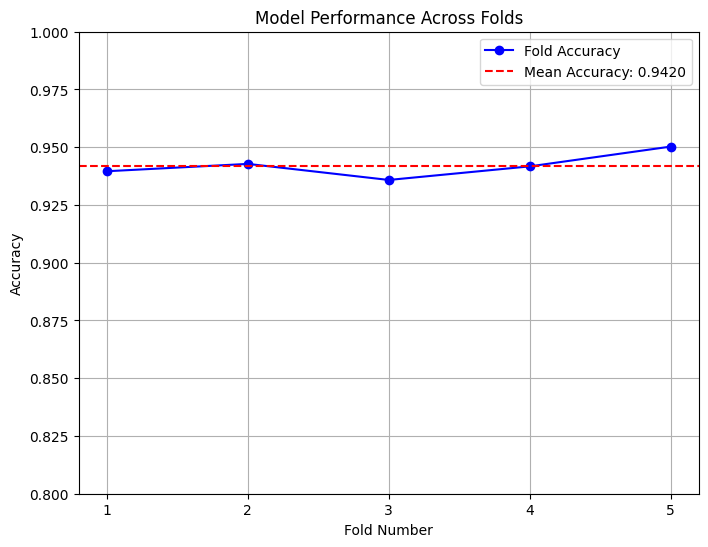

Accuracy Score per Fold: [0.93960449 0.94278075 0.93582888 0.94171123 0.95026738]
Overall Mean Accuracy: 0.9420


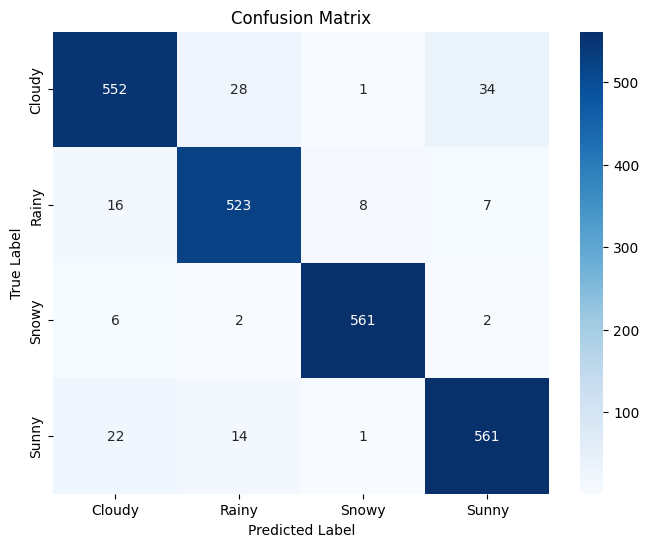

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       615
           1       0.92      0.94      0.93       554
           2       0.98      0.98      0.98       571
           3       0.93      0.94      0.93       598

    accuracy                           0.94      2338
   macro avg       0.94      0.94      0.94      2338
weighted avg       0.94      0.94      0.94      2338



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

file_path = "cleaned - weather_classification_data.csv"
df = pd.read_csv(file_path)

X = df.drop(columns=["Weather Type"])
y = df["Weather Type"]

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(C=1, solver="saga", max_iter=5000) #multi_class="multinomial"

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring="accuracy")

model.fit(X_train_scaled, y_train)

y_pred1 = model.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(scores)+1), scores, marker="o", linestyle="-", color="blue", label="Fold Accuracy")
plt.axhline(y=scores.mean(), color="red", linestyle="--", label=f"Mean Accuracy: {scores.mean():.4f}")
plt.title("Model Performance Across Folds")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.xticks(range(1, len(scores) + 1))
plt.ylim(0.8, 1.0)
plt.legend()
plt.grid(True)

plt.show()

print(f"Accuracy Score per Fold: {scores}")
print(f"Overall Mean Accuracy: {scores.mean():.4f}")

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred1), annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred1))

Out of the 10 experiments, Experiment 6 is the best option as it was found to have the best balance between accuracy, efficiency, and stability of validations. Although Experiment 1 had a robust baseline, Experiment 6 not only replicated the same 94.20% accuracy but utilized "saga", which is more efficient when dealing with big datasets like the weather classification dataset at hand.

Experiment 8 with C value 100 had the best accuracy at 94.24%, but the 0.0004% improvement was insignificant and threatened overfitting. Experiment 4 with a C value of 10 using a "lbfgs" solver was as good with an accuracy of 94.21% but was more computationally intensive without obvious advantages. Experiment 6 with a C value of 1 offered the best connection between regularization and efficiency. Experiment 6 is the strongest model, and it provides effective generalization together with computational feasibility, so this is the strongest model for the given dataset.